In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'notebook'])
import matplotlib as mpl
import matplotlib.ticker as ticker

mpl.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['Computer Modern Roman'],
    'text.usetex':       True,
    'font.size':         9,
    'axes.labelsize':    9,
    'legend.fontsize':   8,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'axes.linewidth':    0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.minor.width': 0.5,  # fix: minor ticks same weight as major
    'ytick.minor.width': 0.5,
    'xtick.major.size':  3,
    'ytick.major.size':  3,
    'xtick.minor.size':  1.5,
    'ytick.minor.size':  1.5,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.top':         True,
    'ytick.right':       True,
    'figure.dpi':        300,
})

colors  = ['#03AED2', '#D12052', '#F8DE22', '#F45B26']
markers = ['o', 's', '^', 'D']
# ms      = 9
# max_bands1 = 9


# max_bands2 = 12
# fig, ax = plt.subplots(figsize=(3.4, 2.8))

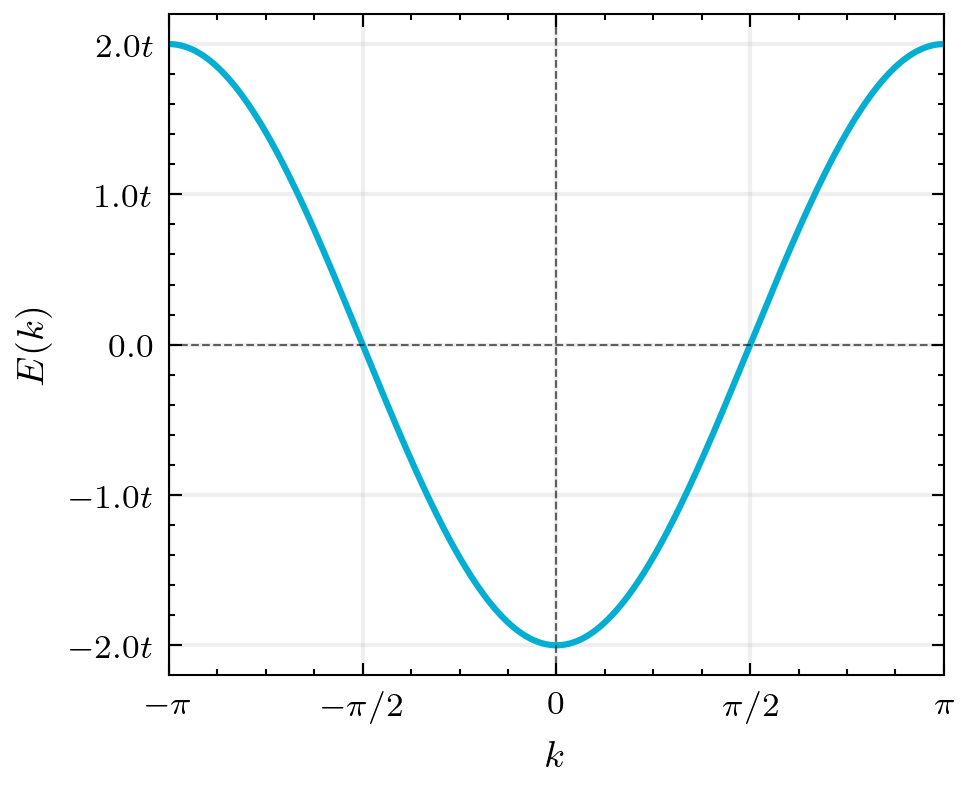

In [26]:
# ----- Tight-binding 1D dispersion: E(k) = -2t cos(k a) -----
t = 1.0      # hopping amplitude
a = 1.0      # lattice constant

k = np.linspace(-np.pi/a, np.pi/a, 400)
E = -2 * t * np.cos(k * a)

fig, ax = plt.subplots(figsize=(3.4, 2.8))

ax.plot(k, E, color=colors[0], lw=1.5)

ax.set_xlim(-np.pi/a, np.pi/a)
ax.set_xticks([-np.pi/a, -np.pi/(2*a), 0, np.pi/(2*a), np.pi/a])
ax.set_xticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])

ax.set_xlabel(r'$k$')
ax.set_ylabel(r'$E(k)$')

# --- y-axis ticks in units of t ---
yticks = np.array([-2.0, -1.0, 0.0, 1.0, 2.0]) * t
ax.set_yticks(yticks)
ax.set_yticklabels([r'$-2.0t$', r'$-1.0t$', r'$0.0$', r'$1.0t$', r'$2.0t$'])

ax.axhline(0, color='k', lw=0.5, ls='--', alpha=0.6)
ax.axvline(0, color='k', lw=0.5, ls='--', alpha=0.6)

ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
# no minor locator on y since ticks are now custom/non-uniform
plt.grid(True, alpha=0.2)
fig.tight_layout()
# fig.savefig('tight_binding_1d_dispersion.pdf', bbox_inches='tight')
plt.show()

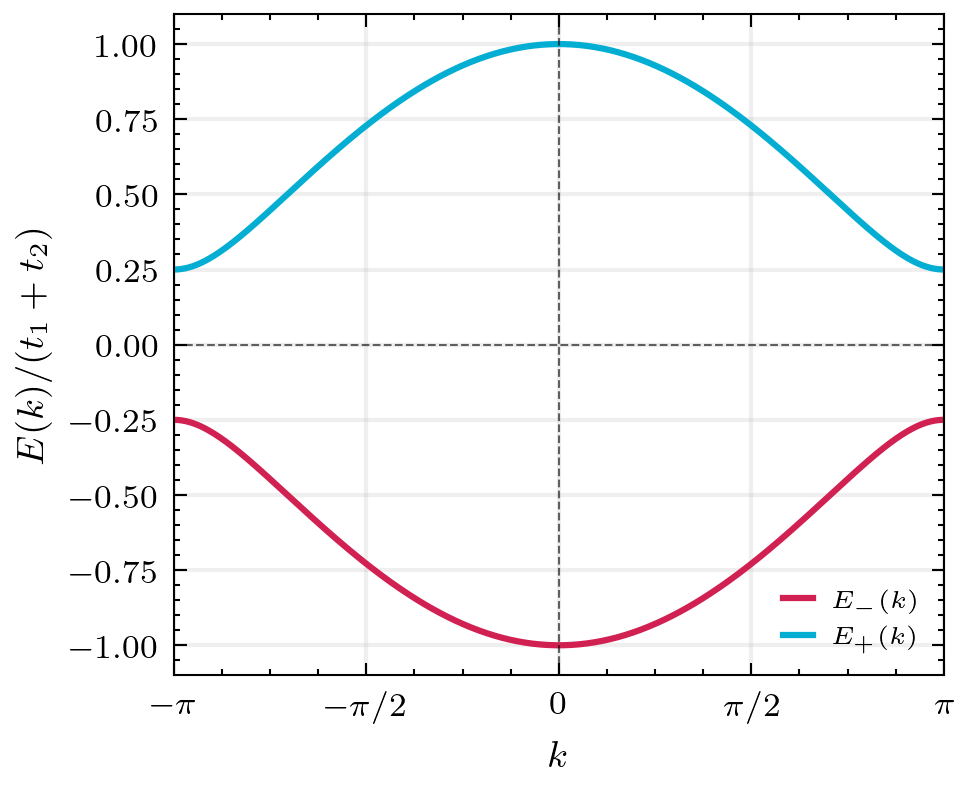

In [27]:
# ----- SSH model dispersion relation (normalized by t1 + t2) -----
# H(k) = [[0, t1 + t2*exp(-i k a)], [t1 + t2*exp(i k a), 0]]
# E_±(k) = ± | t1 + t2 * exp(i k a) |

t1 = 1.0     # intracell hopping
t2 = 0.6     # intercell hopping (t1 != t2 -> dimerization/gap)
a  = 1.0     # unit cell lattice constant
tsum = t1 + t2

k = np.linspace(-np.pi/a, np.pi/a, 400)

# complex structure factor
f_k = t1 + t2 * np.exp(1j * k * a)
E_plus  = np.abs(f_k) / tsum     # upper band, normalized
E_minus = -np.abs(f_k) / tsum    # lower band, normalized

fig, ax = plt.subplots(figsize=(3.4, 2.8))

ax.plot(k, E_minus, color='#D12052', lw=1.5, label=r'$E_-(k)$')
ax.plot(k, E_plus,  color='#03AED2', lw=1.5, label=r'$E_+(k)$')

ax.set_xlim(-np.pi/a, np.pi/a)
ax.set_xticks([-np.pi/a, -np.pi/(2*a), 0, np.pi/(2*a), np.pi/a])
ax.set_xticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])

ax.set_xlabel(r'$k$')
ax.set_ylabel(r'$E(k)/(t_1+t_2)$')

ax.axhline(0, color='k', lw=0.5, ls='--', alpha=0.6)
ax.axvline(0, color='k', lw=0.5, ls='--', alpha=0.6)

ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

ax.legend(frameon=False, loc='lower right', ncol=1, fontsize=6, handlelength=1.2)
plt.grid(True, alpha=0.2)
fig.tight_layout()
# fig.savefig('ssh_dispersion.pdf', bbox_inches='tight')
plt.show()

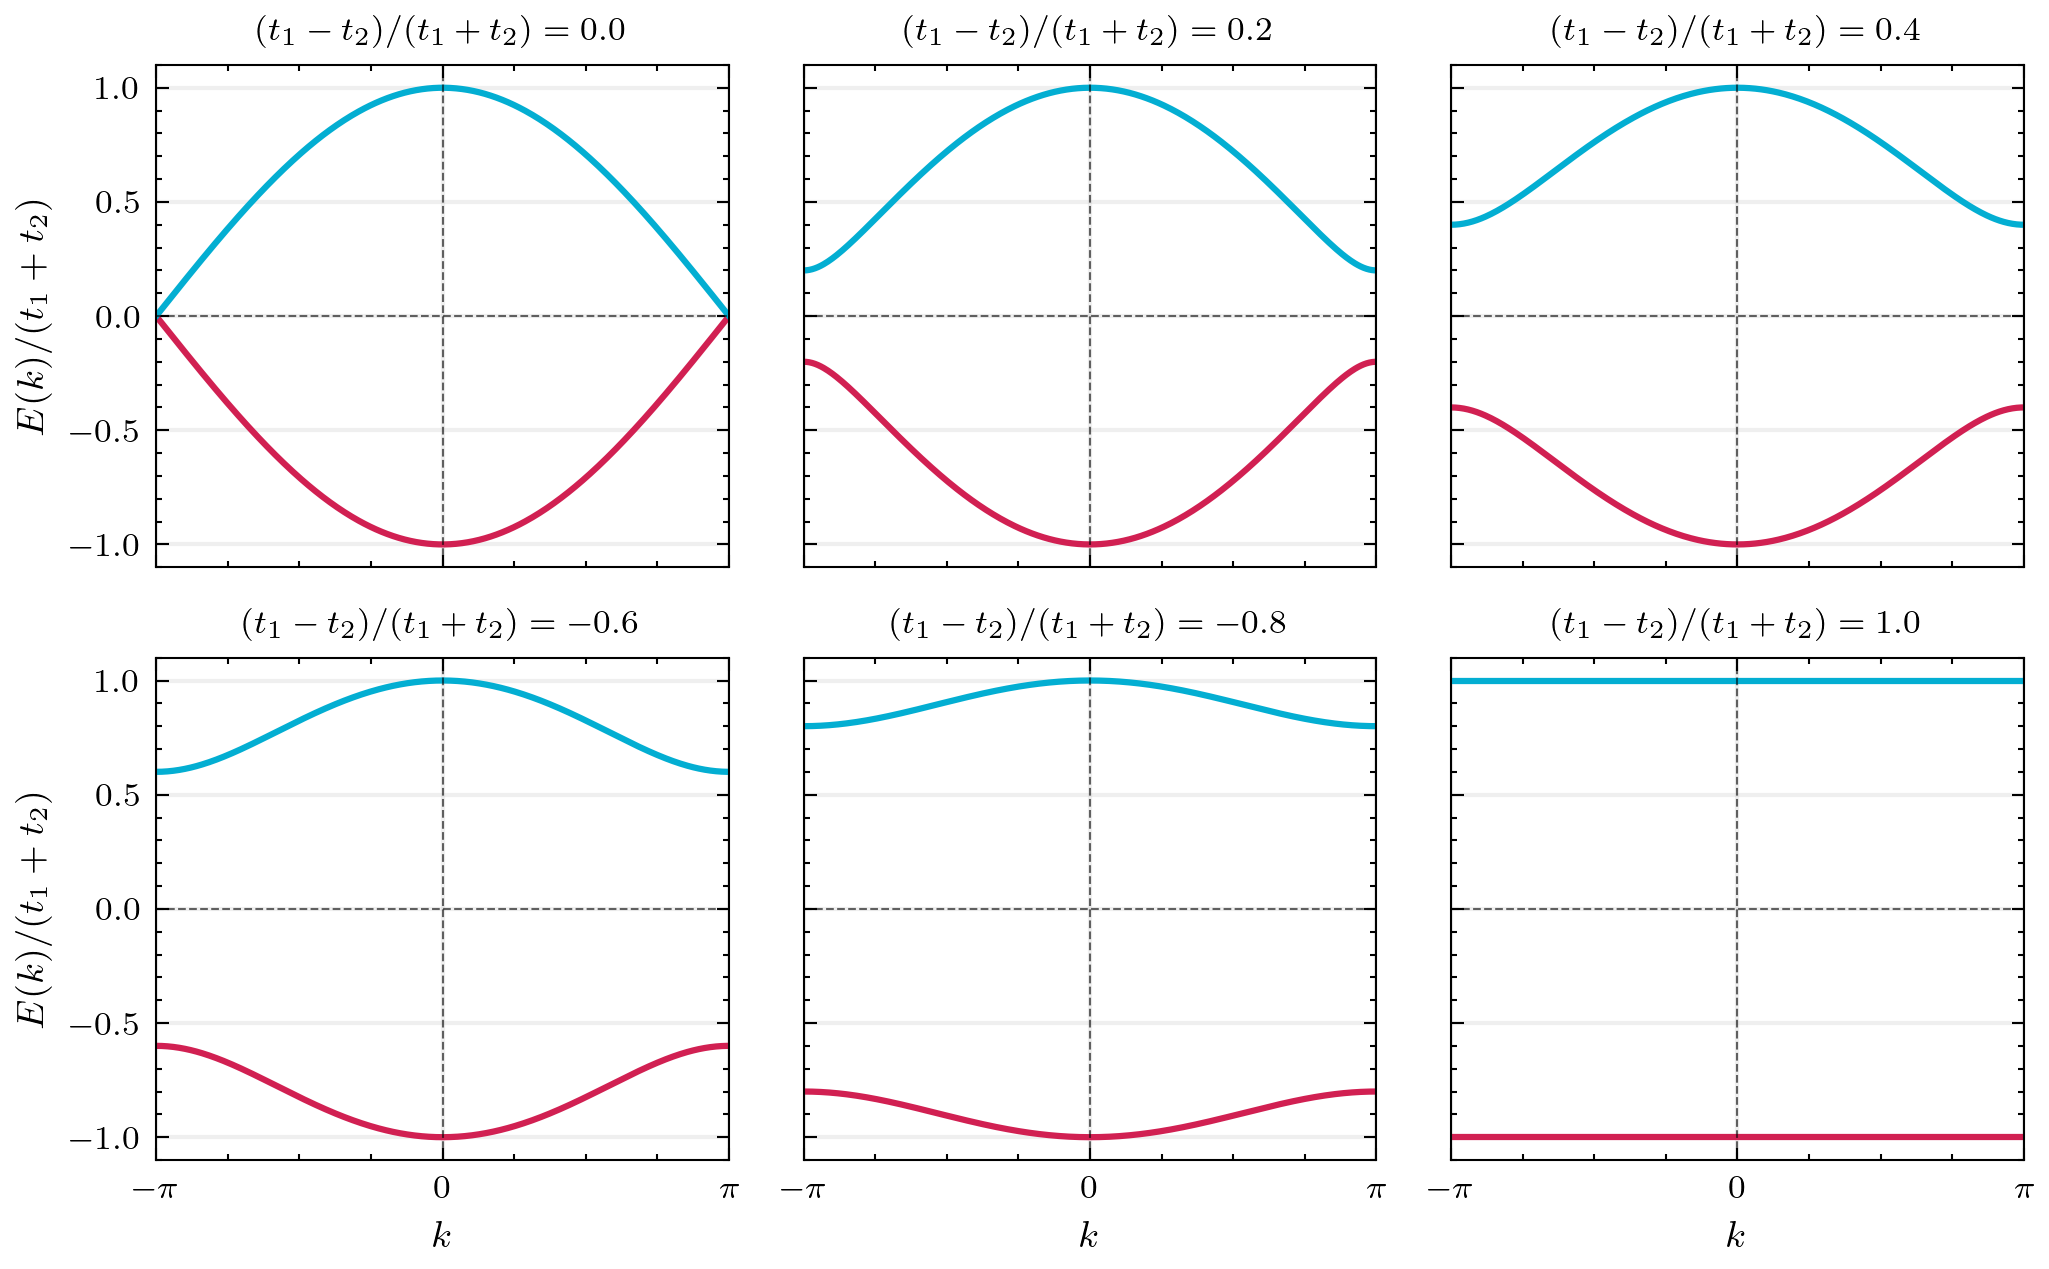

In [28]:
# ----- SSH model dispersion for various dimerization ratios -----
# Fix t1 + t2 = 1, so t1 = (1+r)/2, t2 = (1-r)/2, where r = |t1-t2|/(t1+t2)

a = 1.0
k = np.linspace(-np.pi/a, np.pi/a, 400)

ratios = [0.0, 0.2, 0.4, -0.6, -0.8, 1.0]   # |t1 - t2| / (t1 + t2)

fig, axes = plt.subplots(2, 3, figsize=(7.0, 4.4), sharex=True, sharey=True)

for ax, r in zip(axes.flat, ratios):
    t1 = (1 + r) / 2
    t2 = (1 - r) / 2
    tsum = t1 + t2   # = 1 by construction, kept explicit for clarity

    f_k = t1 + t2 * np.exp(1j * k * a)
    E_plus  = np.abs(f_k) / tsum
    E_minus = -np.abs(f_k) / tsum

    ax.plot(k, E_minus, color='#D12052', lw=1.5)
    ax.plot(k, E_plus,  color='#03AED2', lw=1.5)

    ax.set_xlim(-np.pi/a, np.pi/a)
    ax.set_ylim(-1.1, 1.1)
    ax.set_xticks([-np.pi/a, 0, np.pi/a])
    ax.set_xticklabels([r'$-\pi$', r'$0$', r'$\pi$'])

    ax.axhline(0, color='k', lw=0.5, ls='--', alpha=0.6)
    ax.axvline(0, color='k', lw=0.5, ls='--', alpha=0.6)

    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(True, alpha=0.2)

    ax.set_title(rf'$(t_1-t_2)/(t_1+t_2) = {r:.1f}$', fontsize=8)

for ax in axes[-1, :]:
    ax.set_xlabel(r'$k$')
for ax in axes[:, 0]:
    ax.set_ylabel(r'$E(k)/(t_1+t_2)$')

fig.tight_layout()
# fig.savefig('ssh_dispersion_grid.pdf', bbox_inches='tight')
plt.show()

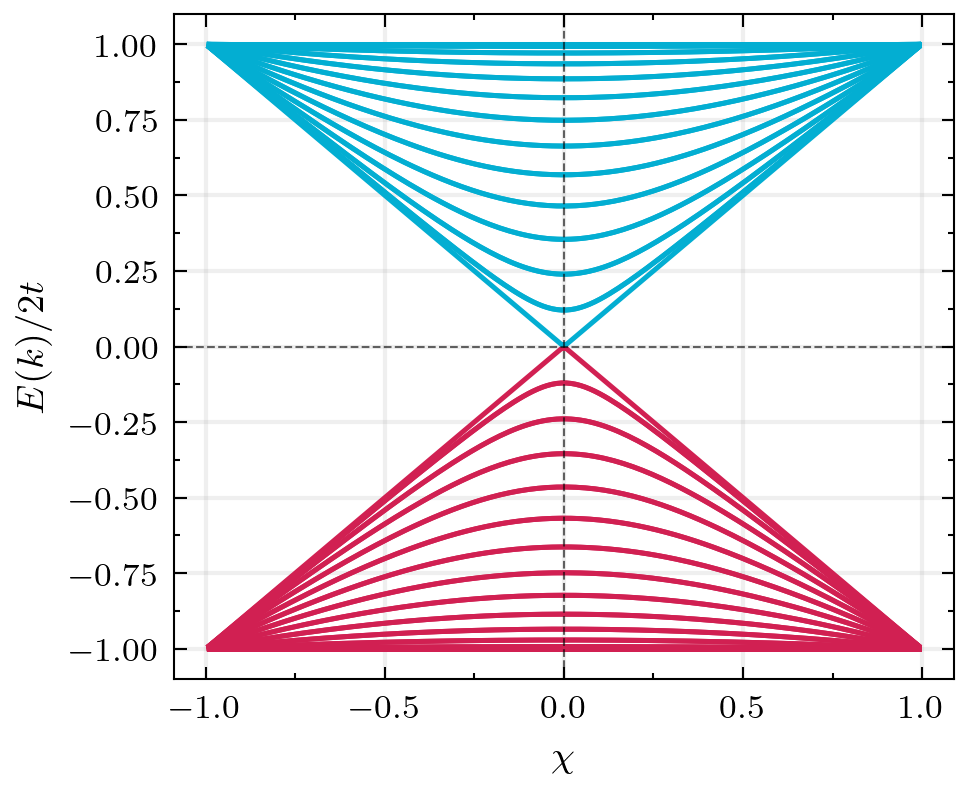

In [30]:
# ------------------------------------------------------------------ #
# Analytical SSH spectrum function (PBC)
# ------------------------------------------------------------------ #
def ssh_spectrum(N, omega_c, chi_c):
    """
    Analytical eigenvalues of the periodic (PBC) SSH chain.

    Conventions:
        2t = t1 + t2  = omega_c
        chi_c = (t1 - t2) / (t1 + t2)

    Returns E_plus, E_minus separately (each length N),
    so band identity is preserved across the chi_c sweep.
    """
    t1 = omega_c * (1 + chi_c) / 2
    t2 = omega_c * (1 - chi_c) / 2

    ks = 2 * np.pi * np.arange(N) / N

    f_k = t1 + t2 * np.exp(1j * ks)
    E_plus  = np.abs(f_k)
    E_minus = -np.abs(f_k)
    return E_plus, E_minus


# ------------------------------------------------------------------ #
# Parameters
# ------------------------------------------------------------------ #
N       = 26
Omega_C = 1.0
Chi_C_values = np.linspace(-0.99, 0.99, 150)

# ------------------------------------------------------------------ #
# Compute spectrum (bands kept separate)
# ------------------------------------------------------------------ #
E_plus_list, E_minus_list = [], []
for Chi_C in Chi_C_values:
    Ep, Em = ssh_spectrum(N=N, omega_c=Omega_C, chi_c=Chi_C)
    E_plus_list.append(Ep)
    E_minus_list.append(Em)

E_plus_arr  = np.array(E_plus_list)    # shape (n_chi, N)
E_minus_arr = np.array(E_minus_list)

scaled_plus  = (E_plus_arr) / Omega_C
scaled_minus = (E_minus_arr) / Omega_C

# ------------------------------------------------------------------ #
# Figure
# ------------------------------------------------------------------ #
fig, ax = plt.subplots(figsize=(3.4, 2.8))

for band in scaled_minus.T:
    ax.plot(Chi_C_values, band, color=colors[1], lw=1.2)   # lower band
for band in scaled_plus.T:
    ax.plot(Chi_C_values, band, color=colors[0], lw=1.2)   # upper band

ax.set_xlabel(r'$\chi$')
ax.set_ylabel(r'$E(k)/2t$')

ax.axhline(0, color='k', lw=0.5, ls='--', alpha=0.6)
ax.axvline(0, color='k', lw=0.5, ls='--', alpha=0.6)

ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))

# ax.set_title(rf'$4g_C / \omega_q = {Omega_C:.2f}$', fontsize=8, pad=4)

plt.grid(True, alpha=0.2)
fig.tight_layout()
# fig.savefig('single_omega_c_bands.pdf', bbox_inches='tight')
plt.show()

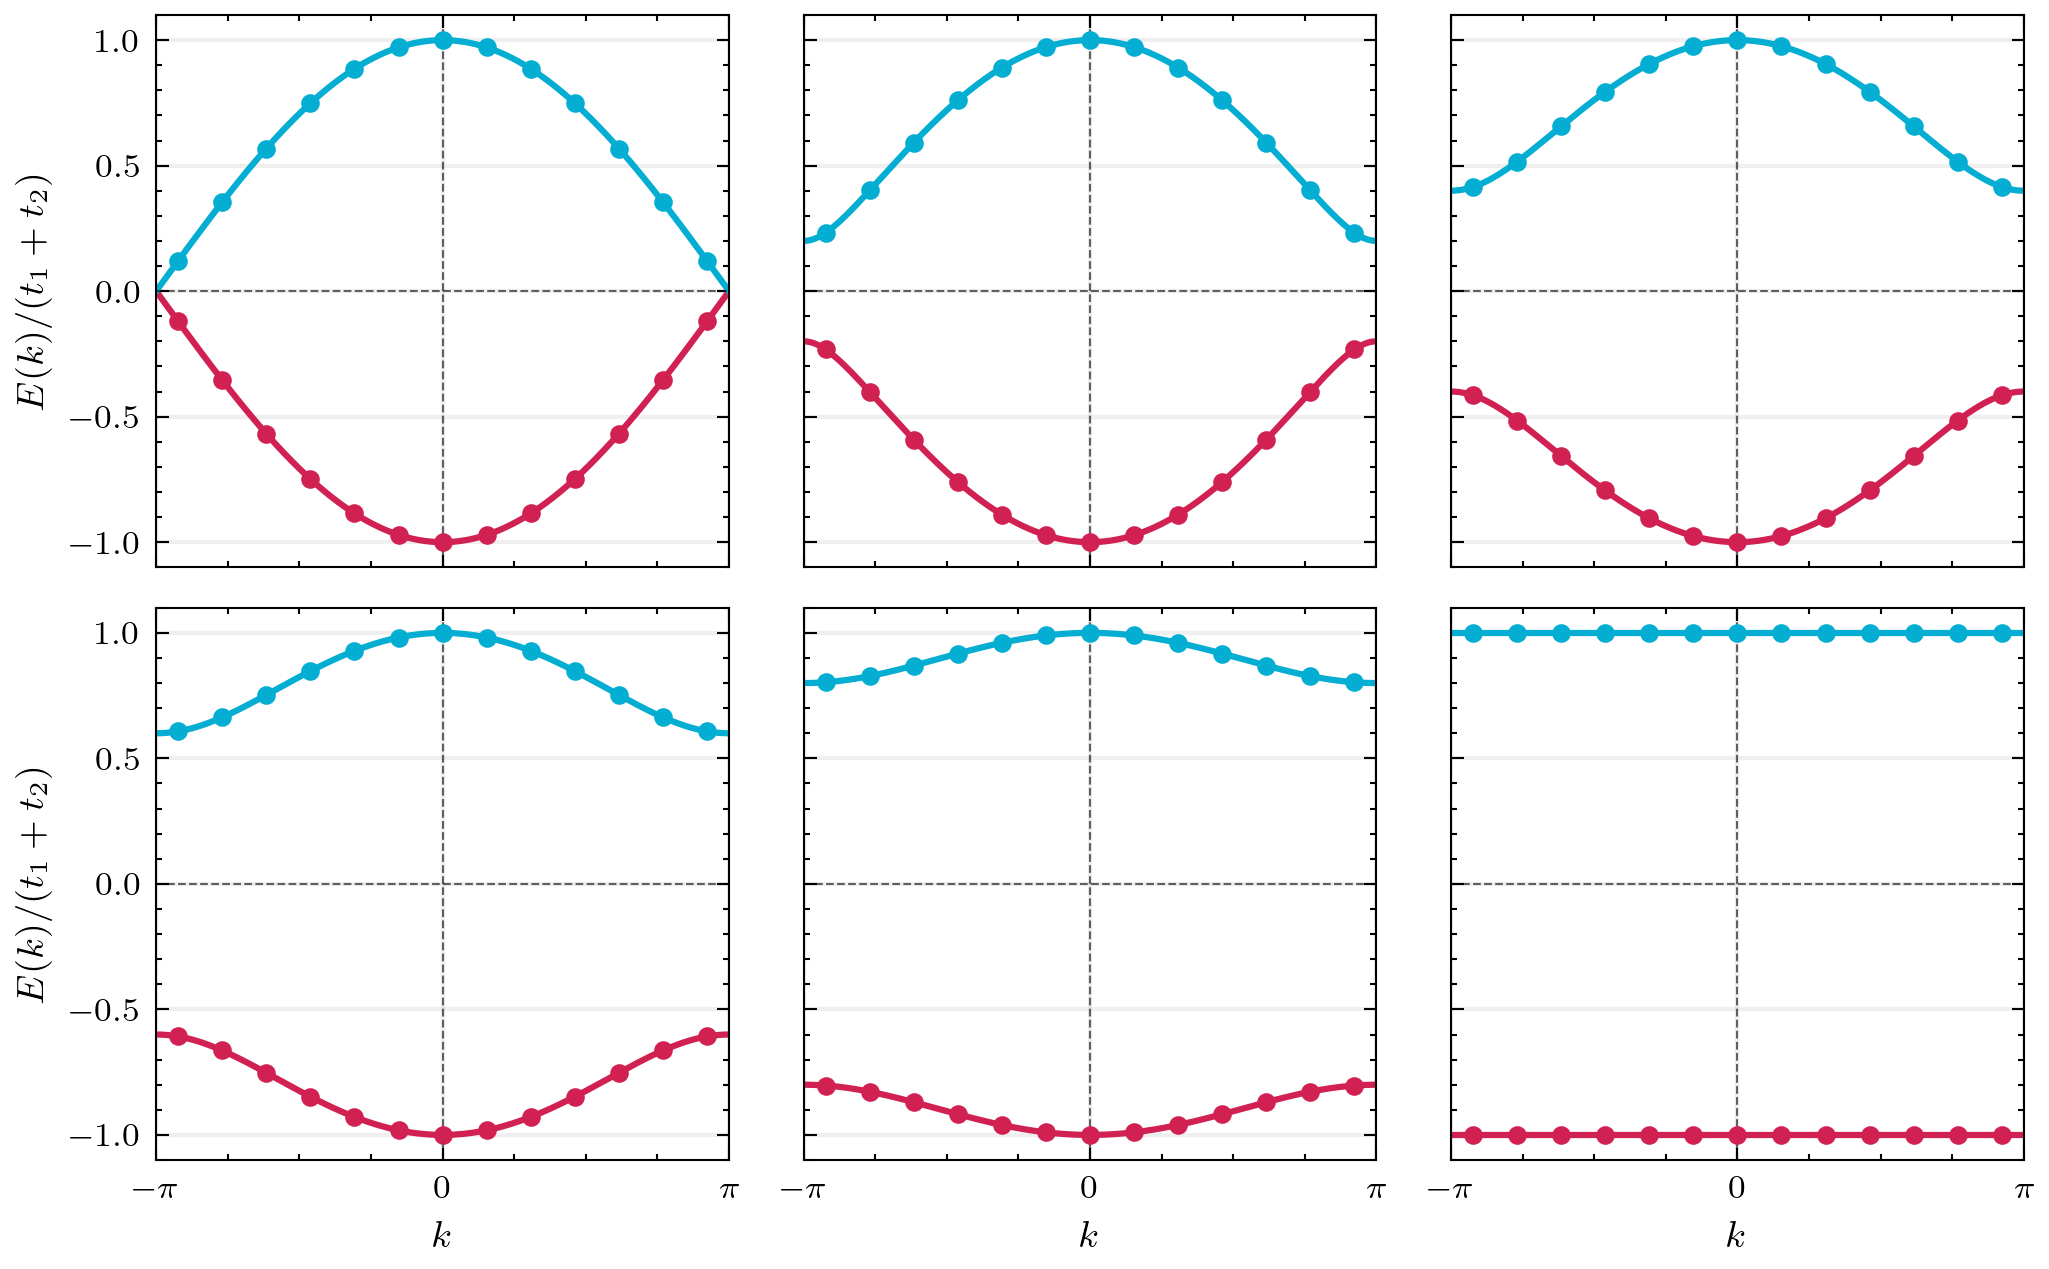

In [31]:
# ----- SSH model dispersion for various dimerization ratios -----
# Fix t1 + t2 = 1, so t1 = (1+r)/2, t2 = (1-r)/2, where r = (t1-t2)/(t1+t2)

a = 1.0
k = np.linspace(-np.pi/a, np.pi/a, 400)

ratios = [0.0, 0.2, 0.4, -0.6, -0.8, 1.0]

# ----- discrete momenta from FFT frequencies (N = 13 points) -----
N = 13
k_discrete = 2 * np.pi * np.fft.fftfreq(N, d=a)
k_discrete = np.sort(k_discrete)

fig, axes = plt.subplots(2, 3, figsize=(7.0, 4.4), sharex=True, sharey=True)

for ax, r in zip(axes.flat, ratios):
    t1 = (1 + r) / 2
    t2 = (1 - r) / 2
    tsum = t1 + t2

    f_k = t1 + t2 * np.exp(1j * k * a)
    E_plus  = np.abs(f_k) / tsum
    E_minus = -np.abs(f_k) / tsum

    ax.plot(k, E_minus, color='#D12052', lw=1.5)
    ax.plot(k, E_plus,  color='#03AED2', lw=1.5)

    f_kd = t1 + t2 * np.exp(1j * k_discrete * a)
    E_plus_d  = np.abs(f_kd) / tsum
    E_minus_d = -np.abs(f_kd) / tsum

    ax.scatter(k_discrete, E_minus_d, color='#D12052', s=12, zorder=3)
    ax.scatter(k_discrete, E_plus_d,  color='#03AED2', s=12, zorder=3)

    ax.set_xlim(-np.pi/a, np.pi/a)
    ax.set_ylim(-1.1, 1.1)
    ax.set_xticks([-np.pi/a, 0, np.pi/a])
    ax.set_xticklabels([r'$-\pi$', r'$0$', r'$\pi$'])

    ax.axhline(0, color='k', lw=0.5, ls='--', alpha=0.6)
    ax.axvline(0, color='k', lw=0.5, ls='--', alpha=0.6)

    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(True, alpha=0.2)

for ax in axes[-1, :]:
    ax.set_xlabel(r'$k$')
for ax in axes[:, 0]:
    ax.set_ylabel(r'$E(k)/(t_1+t_2)$')

fig.tight_layout()
# fig.savefig('ssh_dispersion_grid.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# ------------------------------------------------------------------ #
# Numerical SSH spectrum (OBC)
# ------------------------------------------------------------------ #
def ssh_spectrum_obc(N, omega_c, chi_c):
    """
    Numerical eigenvalues of the open (OBC) SSH chain with N unit cells
    (2N sites total).

    Conventions:
        2t = t1 + t2  = omega_c
        chi_c = (t1 - t2) / (t1 + t2)

    Returns sorted eigenvalues, length 2N.
    """
    t1 = omega_c * (1 + chi_c) / 2
    t2 = omega_c * (1 - chi_c) / 2

    n_sites = 2 * N
    H = np.zeros((n_sites, n_sites))

    for i in range(N):
        a_idx = 2 * i        # sublattice A of cell i
        b_idx = 2 * i + 1    # sublattice B of cell i

        # intracell hopping t1 (A_i - B_i)
        H[a_idx, b_idx] = t1
        H[b_idx, a_idx] = t1

        # intercell hopping t2 (B_i - A_{i+1}), only if not last cell (OBC)
        if i < N - 1:
            a_next = 2 * (i + 1)
            H[b_idx, a_next] = t2
            H[a_next, b_idx] = t2

    eigvals = np.linalg.eigvalsh(H)
    return np.sort(eigvals)


# ------------------------------------------------------------------ #
# Parameters
# ------------------------------------------------------------------ #
N       = 26
Omega_C = 1.0
Chi_C_values = np.linspace(-0.99, 0.99, 150)
edge_thresh  = 0.1

# ------------------------------------------------------------------ #
# Compute spectrum
# ------------------------------------------------------------------ #
energies = []
for Chi_C in Chi_C_values:
    vals = ssh_spectrum_obc(N=N, omega_c=Omega_C, chi_c=Chi_C)
    energies.append(vals)
energies = np.array(energies)   # shape (n_chi, 2N)

scaled = energies / Omega_C

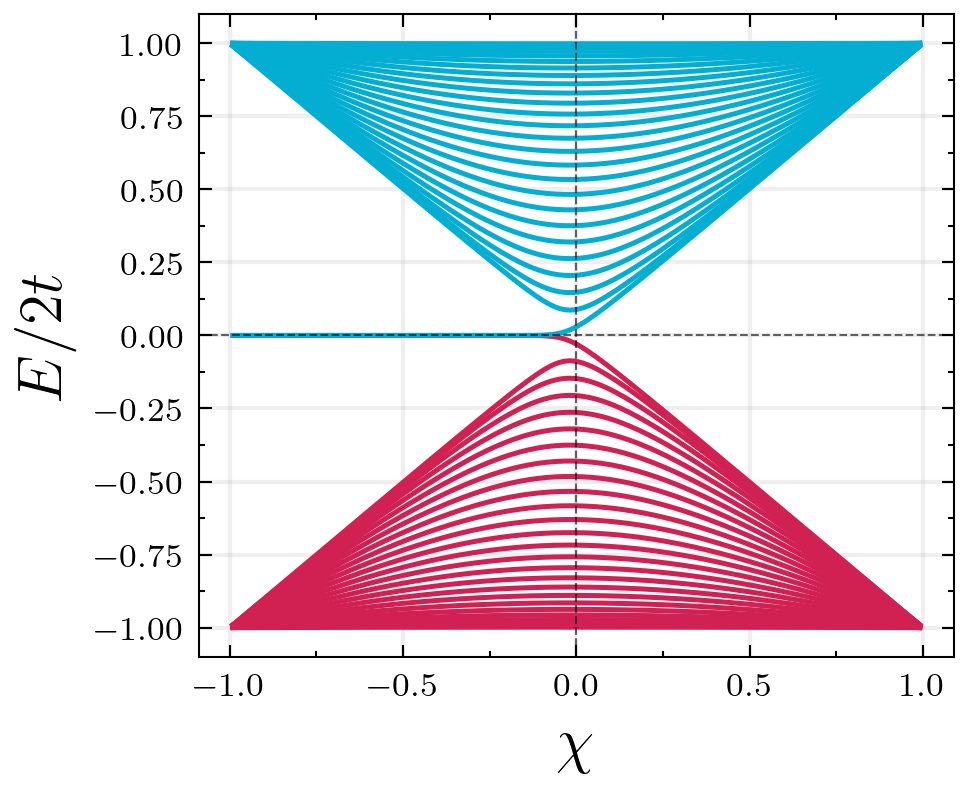

In [36]:
# ------------------------------------------------------------------ #
# Figure
# ------------------------------------------------------------------ #
fig, ax = plt.subplots(figsize=(3.4, 2.8))

for band in scaled.T:
    mean_abs = np.mean(np.abs(band))
    mean_val = np.mean(band)

    if mean_abs < edge_thresh:
        color = colors[2]        # edge states -> third color
    elif mean_val < 0:
        color = colors[1]        # lower bulk band
    else:
        color = colors[0]        # upper bulk band

    ax.plot(Chi_C_values, band, color=color, lw=1.2)

ax.set_xlabel(r'$\chi$', fontsize = 15)
ax.set_ylabel(r'$E/2t$', fontsize = 15)

ax.axhline(0, color='k', lw=0.5, ls='--', alpha=0.6)
ax.axvline(0, color='k', lw=0.5, ls='--', alpha=0.6)

ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))

plt.grid(True, alpha=0.2)
fig.tight_layout()
# fig.savefig('ssh_obc_bands.pdf', bbox_inches='tight')
plt.show()

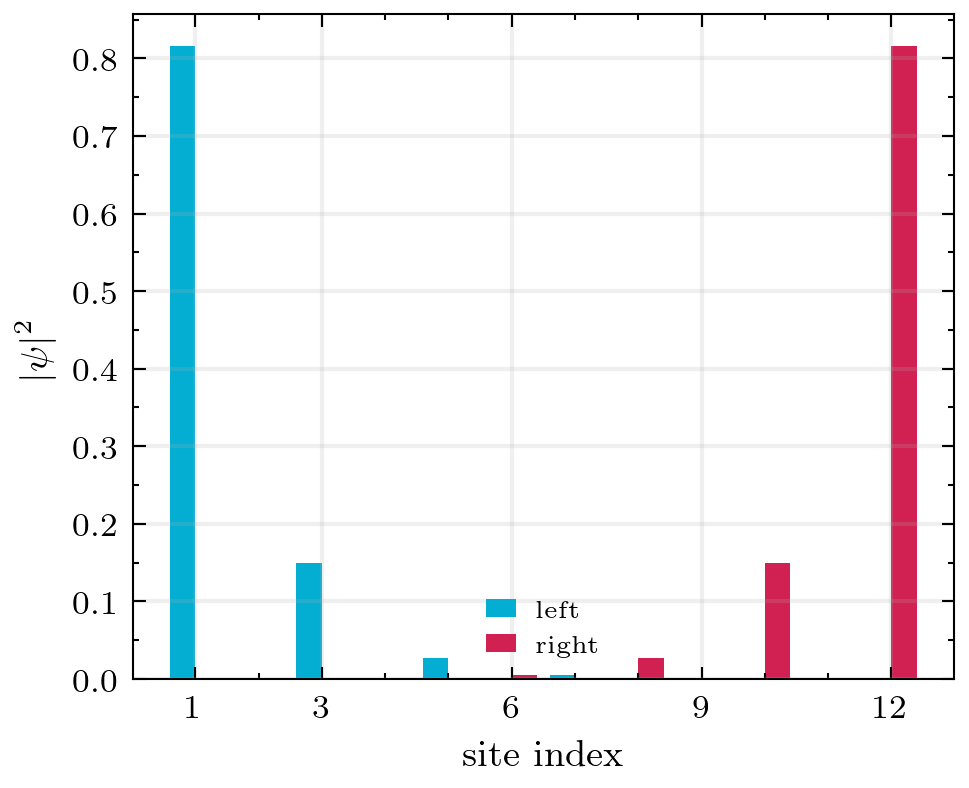

In [ ]:
# ------------------------------------------------------------------ #
# SSH edge-state probability densities: analytical expressions
# ------------------------------------------------------------------ #
N_cells = 6
n_sites = 2 * N_cells

Omega_C = 1.0
Chi_C   = -0.4   # topological phase requires |t1/t2| < 1

t1 = Omega_C * (1 + Chi_C) / 2
t2 = Omega_C * (1 - Chi_C) / 2

n = np.arange(1, N_cells + 1)
ratio = -t1 / t2

# left edge state: nonzero only on sublattice A
psi_A_L = ratio**(n - 1)
psi_B_L = np.zeros(N_cells)

# right edge state: nonzero only on sublattice B
psi_A_R = np.zeros(N_cells)
psi_B_R = ratio**(N_cells - n)

# interleave A/B into full site array (A_1,B_1,A_2,B_2,...)
psi_L = np.empty(n_sites)
psi_L[0::2] = psi_A_L
psi_L[1::2] = psi_B_L

psi_R = np.empty(n_sites)
psi_R[0::2] = psi_A_R
psi_R[1::2] = psi_B_R

# normalize
psi_L /= np.linalg.norm(psi_L)
psi_R /= np.linalg.norm(psi_R)

rho_L = np.abs(psi_L)**2
rho_R = np.abs(psi_R)**2

sites = np.arange(1, n_sites + 1)
bar_width = 0.4

fig, ax = plt.subplots(figsize=(3.4, 2.8))

ax.bar(sites - bar_width/2, rho_L, width=bar_width, color=colors[0], label=r'left')
ax.bar(sites + bar_width/2, rho_R, width=bar_width, color=colors[1], label=r'right')

ax.set_xlabel(r'site index')
ax.set_ylabel(r'$|\psi|^2$')
ax.set_xticks([1, 3, 6, 9, 12])

ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.legend(frameon=False, fontsize=6, handlelength=1.2)
plt.grid(True, alpha=0.2)
fig.tight_layout()
# fig.savefig('ssh_edge_states_analytical_density.pdf', bbox_inches='tight')
plt.show()

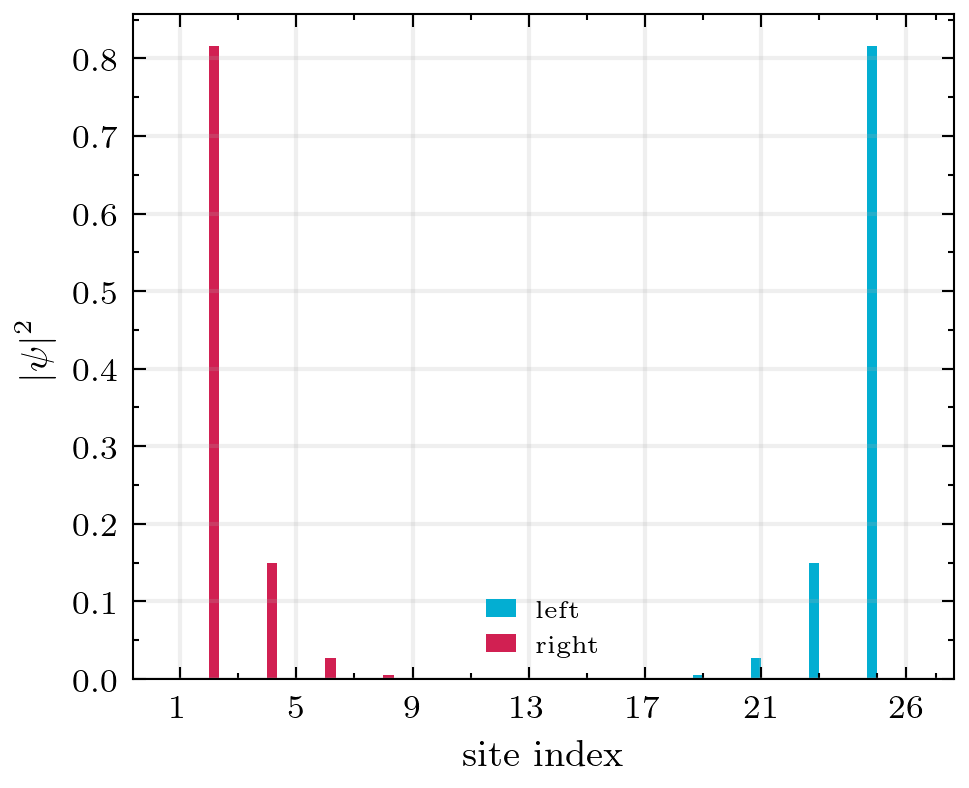

In [31]:
# ------------------------------------------------------------------ #
# SSH edge-state probability densities: analytical expressions
# ------------------------------------------------------------------ #
N_cells = 13
n_sites = 2 * N_cells

Omega_C = 1.0
Chi_C   = 0.4   # topological phase requires |t1/t2| < 1

t1 = Omega_C * (1 + Chi_C) / 2
t2 = Omega_C * (1 - Chi_C) / 2

n = np.arange(1, N_cells + 1)
ratio = -t1 / t2

psi_A_L = ratio**(n - 1)
psi_B_L = np.zeros(N_cells)

psi_A_R = np.zeros(N_cells)
psi_B_R = ratio**(N_cells - n)

psi_L = np.empty(n_sites)
psi_L[0::2] = psi_A_L
psi_L[1::2] = psi_B_L

psi_R = np.empty(n_sites)
psi_R[0::2] = psi_A_R
psi_R[1::2] = psi_B_R

psi_L /= np.linalg.norm(psi_L)
psi_R /= np.linalg.norm(psi_R)

rho_L = np.abs(psi_L)**2
rho_R = np.abs(psi_R)**2

sites = np.arange(1, n_sites + 1)
bar_width = 0.35   # slightly narrower so both bars sit closer to the tick

fig, ax = plt.subplots(figsize=(3.4, 2.8))

ax.bar(sites - bar_width/2, rho_L, width=bar_width, color=colors[0], label=r'left')
ax.bar(sites + bar_width/2, rho_R, width=bar_width, color=colors[1], label=r'right')

ax.set_xlabel(r'site index')
ax.set_ylabel(r'$|\psi|^2$')

# explicit, sparser set of xticks (edit this list as needed)
xticks_shown = [1, 5, 9, 13, 17, 21, 26]
ax.set_xticks(xticks_shown)

ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))

ax.legend(frameon=False, fontsize=6, handlelength=1.2)
plt.grid(True, alpha=0.2)
fig.tight_layout()
# fig.savefig('ssh_edge_states_analytical_density.pdf', bbox_inches='tight')
plt.show()

/tmp/ipykernel_7288/3339846462.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


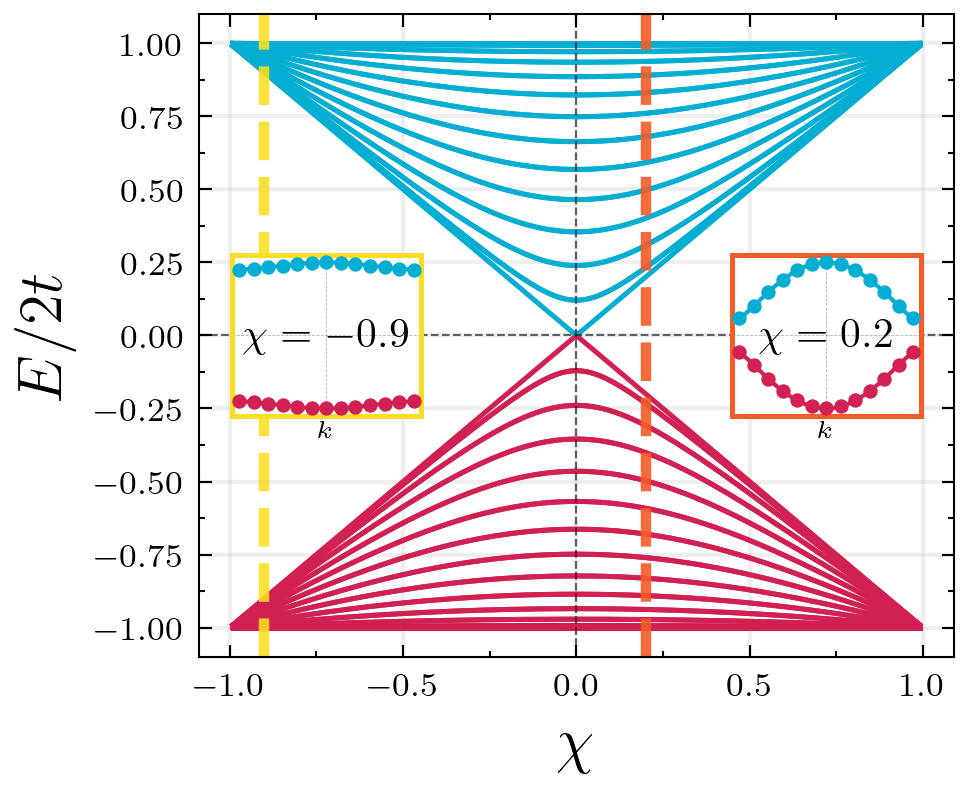

In [24]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ------------------------------------------------------------------ #
# Analytical SSH spectrum function (PBC)
# ------------------------------------------------------------------ #
def ssh_spectrum(N, omega_c, chi_c):
    t1 = omega_c * (1 + chi_c) / 2
    t2 = omega_c * (1 - chi_c) / 2
    ks = 2 * np.pi * np.arange(N) / N
    f_k = t1 + t2 * np.exp(1j * ks)
    E_plus  = np.abs(f_k)
    E_minus = -np.abs(f_k)
    return E_plus, E_minus


# ------------------------------------------------------------------ #
# Parameters
# ------------------------------------------------------------------ #
N       = 26
Omega_C = 1.0
Chi_C_values = np.linspace(-0.99, 0.99, 150)

chi_slices   = [-0.9, 0.2]
slice_colors = ['#F8DE22', '#F45B26']
inset_positions = ["center left", "center right"]

# ------------------------------------------------------------------ #
# Compute main spectrum (bands kept separate)
# ------------------------------------------------------------------ #
E_plus_list, E_minus_list = [], []
for Chi_C in Chi_C_values:
    Ep, Em = ssh_spectrum(N=N, omega_c=Omega_C, chi_c=Chi_C)
    E_plus_list.append(Ep)
    E_minus_list.append(Em)

E_plus_arr  = np.array(E_plus_list)
E_minus_arr = np.array(E_minus_list)

scaled_plus  = E_plus_arr / Omega_C
scaled_minus = E_minus_arr / Omega_C

# ------------------------------------------------------------------ #
# Figure: main panel
# ------------------------------------------------------------------ #
fig, ax = plt.subplots(figsize=(3.4, 2.8))

for band in scaled_minus.T:
    ax.plot(Chi_C_values, band, color=colors[1], lw=1.2)
for band in scaled_plus.T:
    ax.plot(Chi_C_values, band, color=colors[0], lw=1.2)

ax.set_xlabel(r'$\chi$', fontsize=15)
ax.set_ylabel(r'$E/2t$', fontsize=15)

ax.axhline(0, color='k', lw=0.5, ls='--', alpha=0.6)
ax.axvline(0, color='k', lw=0.5, ls='--', alpha=0.6)

ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))

# thicker, colored vertical slice lines
for chi_v, c in zip(chi_slices, slice_colors):
    ax.axvline(chi_v, color=c, lw=2.5, ls='dashed', alpha=0.9)

plt.grid(True, alpha=0.2)

# ------------------------------------------------------------------ #
# Insets: k-space dispersion at each chi slice
# ------------------------------------------------------------------ #
a = 1.0
k = np.linspace(-np.pi/a, np.pi/a, 400)

N_disc = 13
k_discrete = 2 * np.pi * np.fft.fftfreq(N_disc, d=a)
k_discrete = np.sort(k_discrete)

for chi_v, loc, c in zip(chi_slices, inset_positions, slice_colors):
    t1 = Omega_C * (1 + chi_v) / 2
    t2 = Omega_C * (1 - chi_v) / 2
    tsum = t1 + t2

    f_k = t1 + t2 * np.exp(1j * k * a)
    E_plus_k  = np.abs(f_k) / tsum
    E_minus_k = -np.abs(f_k) / tsum

    f_kd = t1 + t2 * np.exp(1j * k_discrete * a)
    E_plus_d  = np.abs(f_kd) / tsum
    E_minus_d = -np.abs(f_kd) / tsum

    axins = inset_axes(ax, width="25%", height="25%", loc=loc, borderpad=1.0)

    axins.plot(k, E_minus_k, color='#D12052', lw=1.0)
    axins.plot(k, E_plus_k,  color='#03AED2', lw=1.0)
    axins.scatter(k_discrete, E_minus_d, color='#D12052', s=6, zorder=3)
    axins.scatter(k_discrete, E_plus_d,  color='#03AED2', s=6, zorder=3)
    axins.set_xlim(-np.pi/a, np.pi/a)
    axins.set_ylim(-1.1, 1.1)
    axins.set_xticks([])
    axins.set_yticks([])
    axins.set_xlabel(r'$k$', fontsize=6, labelpad=1)
    axins.axhline(0, color='k', lw=0.2, ls='--', alpha=0.3)
    axins.axvline(0, color='k', lw=0.2, ls='--', alpha=0.3)

    # legend showing the chi value for this inset
    axins.plot([], [], ' ', label=rf'$\chi = {chi_v:.1f}$')
    axins.legend(frameon=False, fontsize=10, handlelength=0,
                 handletextpad=0, loc='center',
                 borderaxespad=0.2)

    for spine in axins.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color(c)

fig.tight_layout()
# fig.savefig('ssh_bands_with_insets.pdf', bbox_inches='tight')
plt.show()